# AgroScan — Jalon 4 : Entraînement Mixte et Augmentation Renforcée

## Stratégie jalon 4 — trois innovations

### Innovation 1 : Entraînement mixte en Phase 3 (replay d'expériences)
Au lieu de fine-tuner **uniquement** sur PlantDoc, Phase 3 mélange :
- **70 %** des samples proviennent de PlantDoc (images terrain, augmentation renforcée)
- **30 %** proviennent d'un **replay PlantVillage** (uniquement les 27 classes mappées à PlantDoc)

Ce mécanisme de *experience replay* (inspiré de l'apprentissage continu) :
- Réduit l'oubli catastrophique en révisant régulièrement la connaissance PV
- Améliore PlantDoc via plus de diversité et d'augmentation
- Cible uniquement les 27 classes communes pour éviter les gradients conflictuels

### Innovation 2 : Augmentation renforcée pour PlantDoc
- **Flou aléatoire** par average pooling (simulation défocus, prob. 40 %)
- Bruit gaussien plus fort (stddev 10 → 18)
- Rotations et zooms plus agressifs

### Innovation 3 : Dégel progressif accru en Phase 3
- Phase 2 : 25 % du backbone dégelé (comme jalon 3)
- Phase 3 : **40 % du backbone dégelé** → adaptation plus profonde

### Innovation 4 : LR schedule cosinus avec warmup + label smoothing
- 3 époques de warmup linéaire
- Décroissance cosinus : `LR_P3 → 0.01 × LR_P3`
- Label smoothing ε = 0.05 pour mieux généraliser sur petit dataset

**Objectif jalon 4 :** PlantDoc > 55 %, PlantVillage ≥ 40 %

## 1. Lancement

```bash
./scripts/tf_gpu_env.sh uv run jupyter lab
```

In [1]:
# %pip install -r ../requirements.txt kagglehub

In [2]:
import shutil
import subprocess
import os
import time
from pathlib import Path
from difflib import SequenceMatcher
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import classification_report, confusion_matrix, f1_score, accuracy_score

import tensorflow as tf
import tensorflow_datasets as tfds

print('TensorFlow:', tf.__version__)
print('GPU:', tf.config.list_physical_devices('GPU'))

I0000 00:00:1780151909.026934   15018 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1780151909.888372   15018 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
W0000 00:00:1780151910.426473   15018 gpu_device.cc:2459] TensorFlow was not built with CUDA kernel binaries compatible with compute capability 12.0a. CUDA kernels will be jit-compiled from PTX, which could take 30 minutes or longer.


TensorFlow: 2.21.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## 2. Configuration

In [3]:
# ── Détection robuste de la racine projet ──────────────────────────────────
_env_root = Path(os.environ['AGROSCAN_ROOT']) if 'AGROSCAN_ROOT' in os.environ else None
IS_COLAB  = Path('/content').exists() and Path('/opt/google').exists()
_colab_root = Path('/content') if IS_COLAB else None
_cwd = Path('.').resolve()
try:
    _starting_dir = Path(get_ipython().starting_dir).resolve()
except (NameError, AttributeError):
    _starting_dir = _cwd

_candidates = list(dict.fromkeys(filter(None, [
    _env_root, _cwd, _starting_dir, *_cwd.parents, *_starting_dir.parents
])))
ROOT = next(
    (p for p in _candidates if (p / 'requirements.txt').exists()),
    _env_root or _colab_root or _cwd,
)

DATA_DIR   = ROOT / 'data'
MODEL_DIR  = ROOT / 'models'
REPORT_DIR = ROOT / 'reports'

# ── Montage Google Drive (Colab uniquement) ────────────────────────────────
if IS_COLAB:
    try:
        from google.colab import drive as _gdrive
        _gdrive.mount('/content/drive', force_remount=False)
        _drive_root = Path('/content/drive/MyDrive/agroscan')
        MODEL_DIR   = _drive_root / 'models'
        REPORT_DIR  = _drive_root / 'reports'
        print('Google Drive monté → artefacts dans :', _drive_root)
    except Exception as _e:
        print(f'Drive non disponible ({_e}) — sauvegarde locale /content uniquement.')

for d in [MODEL_DIR, REPORT_DIR]:
    d.mkdir(parents=True, exist_ok=True)

IMG_SIZE = (224, 224)
BATCH_SIZE = 32
SEED       = 42
AUTOTUNE   = tf.data.AUTOTUNE

# ── Phase 1 : PlantVillage (backbone gelé) ────────────────────────────────
# +5 epochs et +1 patience vs jalon3 pour mieux converger
EPOCHS_P1   = 15
LR_P1       = 1e-3
PATIENCE_P1 = 3

# ── Phase 2 : PlantWild bridge (25 % backbone dégelé) ────────────────────
# +5 epochs et +1 patience vs jalon3
EPOCHS_P2      = 25
LR_P2          = 1e-4
PATIENCE_P2    = 4
UNFREEZE_RATIO = 0.75   # 75 % gelé → 25 % dégelé (identique jalon 3)

# ── Phase 3 : Entraînement mixte PlantDoc + PV replay (innovations jalon 4) ─
EPOCHS_P3          = 60
LR_P3              = 3e-5
PATIENCE_P3        = 8
UNFREEZE_RATIO_P3  = 0.60   # 60 % gelé → 40 % dégelé (vs 75 % en jalon 3)
MIX_RATIO_PD       = 0.70   # 70 % PlantDoc (augmentation renforcée)
MIX_RATIO_PV       = 0.30   # 30 % PV replay (27 classes mappées uniquement)
LABEL_SMOOTHING_P3 = 0.05   # Réduit la sur-confiance sur petit dataset

tf.keras.utils.set_random_seed(SEED)
print('Racine projet:', ROOT)
print('Models      :', MODEL_DIR)

Racine projet: /home/leonard/UQAC/8INF934 - Atelier Pratique IA I/Projet/AgroScan
Models      : /home/leonard/UQAC/8INF934 - Atelier Pratique IA I/Projet/AgroScan/models


## 3. Chargement de PlantVillage

In [4]:
(pv_train_raw, pv_val_raw, pv_test_raw), info = tfds.load(
    'plant_village',
    split=['train[:70%]', 'train[70%:85%]', 'train[85%:]'],
    as_supervised=True,
    with_info=True,
    data_dir=str(DATA_DIR / 'tfds'),
)

class_names     = info.features['label'].names
num_classes     = len(class_names)
pv_label_to_idx = {name: idx for idx, name in enumerate(class_names)}

print(f'PlantVillage : {num_classes} classes')
print(f'Ex. : {class_names[:5]}')

PlantVillage : 38 classes
Ex. : ['Apple___Apple_scab', 'Apple___Black_rot', 'Apple___Cedar_apple_rust', 'Apple___healthy', 'Blueberry___healthy']


W0000 00:00:1780151910.603093   15018 gpu_device.cc:2459] TensorFlow was not built with CUDA kernel binaries compatible with compute capability 12.0a. CUDA kernels will be jit-compiled from PTX, which could take 30 minutes or longer.


## 4. Configuration PlantDoc

In [5]:
PLANTDOC_DIR       = DATA_DIR / 'plantdoc'
PLANTDOC_TRAIN_DIR = PLANTDOC_DIR / 'train'
PLANTDOC_TEST_DIR  = PLANTDOC_DIR / 'test'

plantdoc_to_plantvillage = {
    'Apple Scab Leaf':                       'Apple___Apple_scab',
    'Apple leaf':                            'Apple___healthy',
    'Apple rust leaf':                       'Apple___Cedar_apple_rust',
    'Bell_pepper leaf':                      'Pepper,_bell___healthy',
    'Bell_pepper leaf spot':                 'Pepper,_bell___Bacterial_spot',
    'Blueberry leaf':                        'Blueberry___healthy',
    'Cherry leaf':                           'Cherry___healthy',
    'Corn Gray leaf spot':                   'Corn___Cercospora_leaf_spot Gray_leaf_spot',
    'Corn leaf blight':                      'Corn___Northern_Leaf_Blight',
    'Corn rust leaf':                        'Corn___Common_rust',
    'Peach leaf':                            'Peach___healthy',
    'Potato leaf early blight':              'Potato___Early_blight',
    'Potato leaf late blight':               'Potato___Late_blight',
    'Raspberry leaf':                        'Raspberry___healthy',
    'Soyabean leaf':                         'Soybean___healthy',
    'Squash Powdery mildew leaf':            'Squash___Powdery_mildew',
    'Strawberry leaf':                       'Strawberry___healthy',
    'Tomato Early blight leaf':              'Tomato___Early_blight',
    'Tomato Septoria leaf spot':             'Tomato___Septoria_leaf_spot',
    'Tomato leaf':                           'Tomato___healthy',
    'Tomato leaf bacterial spot':            'Tomato___Bacterial_spot',
    'Tomato leaf late blight':               'Tomato___Late_blight',
    'Tomato leaf mosaic virus':              'Tomato___Tomato_mosaic_virus',
    'Tomato leaf yellow virus':              'Tomato___Tomato_Yellow_Leaf_Curl_Virus',
    'Tomato mold leaf':                      'Tomato___Leaf_Mold',
    'Tomato two spotted spider mites leaf':  'Tomato___Spider_mites Two-spotted_spider_mite',
    'grape leaf':                            'Grape___healthy',
    'grape leaf black rot':                  'Grape___Black_rot',
}

if not PLANTDOC_TEST_DIR.exists():
    print('Téléchargement de PlantDoc...')
    PLANTDOC_DIR.mkdir(parents=True, exist_ok=True)
    tmp = DATA_DIR / '_pd_clone'
    subprocess.run(
        ['git', 'clone', '--depth', '1',
         'https://github.com/pratikkayal/PlantDoc-Dataset.git', str(tmp)],
        check=True,
    )
    for split in ('train', 'test'):
        src, dst = tmp / split, PLANTDOC_DIR / split
        if src.exists() and not dst.exists():
            shutil.copytree(src, dst)
    shutil.rmtree(tmp)
    print('PlantDoc téléchargé.')

plantdoc_classes = sorted(p.name for p in PLANTDOC_TEST_DIR.iterdir() if p.is_dir())
valid_pd_mapping = {
    k: v for k, v in plantdoc_to_plantvillage.items()
    if k in plantdoc_classes and v in class_names
}
print(f'PlantDoc test : {len(plantdoc_classes)} classes | {len(valid_pd_mapping)} évaluables')

PlantDoc test : 27 classes | 27 évaluables


## 5. Chargement et mapping de PlantWild

In [6]:
PLANTWILD_DIR = DATA_DIR / 'plantwild'

if not PLANTWILD_DIR.exists():
    print('PlantWild non trouvé. Tentative de téléchargement via kagglehub...')
    try:
        import kagglehub
        path = kagglehub.dataset_download('thuanai1/plantwild')
        PLANTWILD_DIR = Path(path)
        print('Téléchargé dans :', PLANTWILD_DIR)
    except Exception as e:
        raise FileNotFoundError(
            f'PlantWild non trouvé ({e}).\n'
            'Télécharger sur https://www.kaggle.com/datasets/thuanai1/plantwild\n'
            'et extraire dans data/plantwild/ (train/ val/)'
        ) from e

for candidate in [PLANTWILD_DIR, PLANTWILD_DIR / 'plantwild', *list(PLANTWILD_DIR.iterdir())]:
    if (candidate / 'train').exists():
        PLANTWILD_TRAIN_DIR = candidate / 'train'
        PLANTWILD_VAL_DIR   = candidate / 'val'
        break
else:
    raise FileNotFoundError(f'Structure train/ introuvable dans {PLANTWILD_DIR}')

print('PlantWild train :', PLANTWILD_TRAIN_DIR)

PlantWild train : /home/leonard/UQAC/8INF934 - Atelier Pratique IA I/Projet/AgroScan/data/plantwild/train


In [7]:
plantwild_to_plantvillage = {
    'apple scab':                    'Apple___Apple_scab',
    'apple black rot':               'Apple___Black_rot',
    'apple rust':                    'Apple___Cedar_apple_rust',
    'apple leaf':                    'Apple___healthy',
    'blueberry leaf':                'Blueberry___healthy',
    'cherry leaf':                   'Cherry___healthy',
    'cherry powdery mildew':         'Cherry___Powdery_mildew',
    'corn gray leaf spot':           'Corn___Cercospora_leaf_spot Gray_leaf_spot',
    'corn leaf blight':              'Corn___Northern_Leaf_Blight',
    'corn rust':                     'Corn___Common_rust',
    'corn leaf':                     'Corn___healthy',
    'grape black rot':               'Grape___Black_rot',
    'grape esca':                    'Grape___Esca_(Black_Measles)',
    'grape leaf blight':             'Grape___Leaf_blight_(Isariopsis_Leaf_Spot)',
    'grape leaf':                    'Grape___healthy',
    'orange citrus greening':        'Orange___Haunglongbing_(Citrus_greening)',
    'orange haunglongbing':          'Orange___Haunglongbing_(Citrus_greening)',
    'peach bacterial spot':          'Peach___Bacterial_spot',
    'peach leaf':                    'Peach___healthy',
    'bell pepper leaf spot':         'Pepper,_bell___Bacterial_spot',
    'bell pepper leaf':              'Pepper,_bell___healthy',
    'potato early blight':           'Potato___Early_blight',
    'potato late blight':            'Potato___Late_blight',
    'potato leaf':                   'Potato___healthy',
    'raspberry leaf':                'Raspberry___healthy',
    'soybean leaf':                  'Soybean___healthy',
    'squash powdery mildew':         'Squash___Powdery_mildew',
    'strawberry leaf scorch':        'Strawberry___Leaf_scorch',
    'strawberry leaf':               'Strawberry___healthy',
    'tomato bacterial spot':         'Tomato___Bacterial_spot',
    'tomato early blight':           'Tomato___Early_blight',
    'tomato late blight':            'Tomato___Late_blight',
    'tomato leaf mold':              'Tomato___Leaf_Mold',
    'tomato septoria leaf spot':     'Tomato___Septoria_leaf_spot',
    'tomato spider mites':           'Tomato___Spider_mites Two-spotted_spider_mite',
    'tomato target spot':            'Tomato___Target_Spot',
    'tomato yellow leaf curl virus': 'Tomato___Tomato_Yellow_Leaf_Curl_Virus',
    'tomato mosaic virus':           'Tomato___Tomato_mosaic_virus',
    'tomato leaf':                   'Tomato___healthy',
}

print(f'Mapping PlantWild → PV : {len(plantwild_to_plantvillage)} entrées')

Mapping PlantWild → PV : 39 entrées


In [8]:
def fuzzy_match(query, candidates, threshold=0.7):
    best, best_score = None, 0.0
    for c in candidates:
        score = SequenceMatcher(None, query, c).ratio()
        if score > best_score:
            best, best_score = c, score
    return best if best_score >= threshold else None


def load_plantwild_split(split_dir):
    image_exts = {'.jpg', '.jpeg', '.png', '.bmp', '.webp'}
    paths, labels = [], []
    unmapped = {}
    for cls_dir in sorted(split_dir.iterdir()):
        if not cls_dir.is_dir():
            continue
        cls_name = cls_dir.name.lower()
        pv_cls = plantwild_to_plantvillage.get(cls_name)
        if pv_cls is None:
            match = fuzzy_match(cls_name, list(plantwild_to_plantvillage.keys()))
            if match:
                pv_cls = plantwild_to_plantvillage[match]
        if pv_cls is None or pv_cls not in pv_label_to_idx:
            imgs = [f for f in cls_dir.iterdir() if f.is_file() and f.suffix.lower() in image_exts]
            unmapped[cls_dir.name] = len(imgs)
            continue
        pv_idx = pv_label_to_idx[pv_cls]
        for p in cls_dir.iterdir():
            if p.is_file() and p.suffix.lower() in image_exts:
                paths.append(str(p))
                labels.append(pv_idx)
    return paths, labels, unmapped


pw_train_paths, pw_train_labels, pw_unmapped = load_plantwild_split(PLANTWILD_TRAIN_DIR)

if PLANTWILD_VAL_DIR.exists():
    pw_val_paths, pw_val_labels, _ = load_plantwild_split(PLANTWILD_VAL_DIR)
else:
    rng = np.random.default_rng(SEED)
    perm = rng.permutation(len(pw_train_paths))
    pw_train_paths  = [pw_train_paths[i]  for i in perm]
    pw_train_labels = [pw_train_labels[i] for i in perm]
    n_val = int(0.2 * len(pw_train_paths))
    pw_val_paths,   pw_val_labels   = pw_train_paths[:n_val],  pw_train_labels[:n_val]
    pw_train_paths, pw_train_labels = pw_train_paths[n_val:],  pw_train_labels[n_val:]

print(f'PlantWild train : {len(pw_train_paths):,} images | val : {len(pw_val_labels):,}')
print(f'Classes couvertes : {len(set(pw_train_labels))} / {num_classes}')

PlantWild train : 7,984 images | val : 1,119
Classes couvertes : 33 / 38


## 6. Pipelines d'augmentation

Deux pipelines distincts :
- **Standard** : utilisé pour PV (Phase 1), PlantWild (Phase 2) et le replay PV (Phase 3)
- **Renforcée** : utilisé pour PlantDoc en Phase 3 uniquement — simule conditions terrain difficiles

In [9]:
def apply_random_blur(image):
    """Flou boîte aléatoire par average pooling (probabilité 40 %).

    Simule le défocus de caméra typique des photos terrain prises à la main.
    L'image doit être de shape [H, W, C] float32.
    """
    do_blur = tf.cast(tf.random.uniform([]) < 0.4, tf.float32)
    img_4d  = tf.expand_dims(image, 0)          # [H,W,C] → [1,H,W,C]
    blurred = tf.nn.avg_pool2d(img_4d, ksize=3, strides=1, padding='SAME')
    blurred = tf.squeeze(blurred, 0)             # [1,H,W,C] → [H,W,C]
    return do_blur * blurred + (1.0 - do_blur) * image


# ── Augmentation standard (Phase 1, Phase 2, replay PV en Phase 3) ────────
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip('horizontal_and_vertical', seed=SEED),
    tf.keras.layers.RandomRotation(0.25, seed=SEED),
    tf.keras.layers.RandomZoom((-0.35, 0.10), seed=SEED),
    tf.keras.layers.RandomContrast(0.4, seed=SEED),
    tf.keras.layers.RandomBrightness(0.2, seed=SEED),
    tf.keras.layers.Lambda(
        lambda x: x + tf.random.normal(tf.shape(x), mean=0.0, stddev=10.0),
        name='gaussian_noise_10',
    ),
], name='data_augmentation_standard')


# ── Augmentation renforcée (PlantDoc en Phase 3 uniquement) ───────────────
# Paramètres plus agressifs + flou pour simuler des conditions terrain réalistes
data_augmentation_heavy = tf.keras.Sequential([
    tf.keras.layers.RandomFlip('horizontal_and_vertical', seed=SEED),
    tf.keras.layers.RandomRotation(0.35, seed=SEED),          # 0.25 → 0.35
    tf.keras.layers.RandomZoom((-0.50, 0.15), seed=SEED),     # plus agressif
    tf.keras.layers.RandomContrast(0.6, seed=SEED),            # 0.4 → 0.6
    tf.keras.layers.RandomBrightness(0.4, seed=SEED),          # 0.2 → 0.4
    tf.keras.layers.Lambda(
        lambda x: x + tf.random.normal(tf.shape(x), mean=0.0, stddev=18.0),
        name='gaussian_noise_18',
    ),
    tf.keras.layers.Lambda(apply_random_blur, name='random_blur'),
], name='data_augmentation_heavy')

print('Pipelines d\'augmentation construits.')

Pipelines d'augmentation construits.


In [10]:
def preprocess_pv(image, label, augment=False):
    """Prétraitement pour les images TFDS PlantVillage."""
    image = tf.image.resize(image, IMG_SIZE)
    image = tf.cast(image, tf.float32)
    if augment:
        image = data_augmentation(image, training=True)
    return image, label


def load_image(path, label, augment=False):
    """Charge une image depuis un fichier avec augmentation standard optionnelle."""
    raw = tf.io.read_file(path)
    img = tf.image.decode_image(raw, channels=3, expand_animations=False)
    img.set_shape([None, None, 3])
    img = tf.image.resize(img, IMG_SIZE)
    img = tf.cast(img, tf.float32)
    if augment:
        img = data_augmentation(img, training=True)
    return img, label


def load_image_heavy(path, label):
    """Charge une image PlantDoc avec augmentation RENFORCÉE (Phase 3 uniquement)."""
    raw = tf.io.read_file(path)
    img = tf.image.decode_image(raw, channels=3, expand_animations=False)
    img.set_shape([None, None, 3])
    img = tf.image.resize(img, IMG_SIZE)
    img = tf.cast(img, tf.float32)
    img = data_augmentation_heavy(img, training=True)
    return img, label

## 7. Construction des datasets

In [11]:
# ── Phase 1 : PlantVillage (identique jalon 3) ────────────────────────────
p1_train_ds = (
    pv_train_raw
    .shuffle(4096, seed=SEED)
    .map(lambda x, y: preprocess_pv(x, y, augment=True), num_parallel_calls=AUTOTUNE)
    .batch(BATCH_SIZE)
    .prefetch(AUTOTUNE)
)
p1_val_ds = (
    pv_val_raw
    .map(preprocess_pv, num_parallel_calls=AUTOTUNE)
    .batch(BATCH_SIZE)
    .prefetch(AUTOTUNE)
)

# ── Phase 2 : PlantWild (identique jalon 3) ───────────────────────────────
p2_train_ds = (
    tf.data.Dataset.from_tensor_slices((pw_train_paths, pw_train_labels))
    .shuffle(4096, seed=SEED)
    .map(lambda p, l: load_image(p, l, augment=True), num_parallel_calls=AUTOTUNE)
    .batch(BATCH_SIZE)
    .prefetch(AUTOTUNE)
)
p2_val_ds = (
    tf.data.Dataset.from_tensor_slices((pw_val_paths, pw_val_labels))
    .map(load_image, num_parallel_calls=AUTOTUNE)
    .batch(BATCH_SIZE)
    .prefetch(AUTOTUNE)
)

# ── Collecte images PlantDoc train (pour Phase 3) ─────────────────────────
ft_paths, ft_labels = [], []
for pd_cls, pv_cls in plantdoc_to_plantvillage.items():
    cls_dir = PLANTDOC_TRAIN_DIR / pd_cls
    if not cls_dir.exists() or pv_cls not in pv_label_to_idx:
        continue
    idx = pv_label_to_idx[pv_cls]
    for p in sorted(cls_dir.iterdir()):
        if p.is_file():
            ft_paths.append(str(p))
            ft_labels.append(idx)

rng = np.random.default_rng(SEED)
perm = rng.permutation(len(ft_paths))
ft_paths  = [ft_paths[i]  for i in perm]
ft_labels = [ft_labels[i] for i in perm]

n_val_ft = int(0.2 * len(ft_paths))
ft_val_paths,   ft_val_labels   = ft_paths[:n_val_ft],  ft_labels[:n_val_ft]
ft_train_paths, ft_train_labels = ft_paths[n_val_ft:],  ft_labels[n_val_ft:]

print(f'Phase 1 (PV)      train : {sum(1 for _ in pv_train_raw):,}')
print(f'Phase 2 (Wild)    train : {len(pw_train_paths):,}')
print(f'Phase 3 (PDoc)    train : {len(ft_train_paths):,} | val : {len(ft_val_paths):,}')

Phase 1 (PV)      train : 38,012
Phase 2 (Wild)    train : 7,984
Phase 3 (PDoc)    train : 1,874 | val : 468


### Dataset Phase 3 : Entraînement mixte (innovation principale jalon 4)

**Problème résolu :** dans jalon3, la Phase 3 fine-tune uniquement sur ~1 874 images PlantDoc.
Les gradients sur ce petit dataset écrasent progressivement la connaissance PlantVillage apprise
en Phase 1 → oubli catastrophique (PV : 95 % → 43 %).

**Solution :** `tf.data.Dataset.sample_from_datasets` pour mélanger à chaque batch :
- **70 %** PlantDoc avec augmentation renforcée → adaptation terrain
- **30 %** PlantVillage replay (27 classes mappées) avec augmentation standard → mémoire

Seules les 27 classes PV qui ont un équivalent PlantDoc sont utilisées pour le replay,
ce qui évite les gradients conflictuels sur les classes non terrain.

In [12]:
# ── Identifier les 27 classes PV à rejouer ────────────────────────────────
mapped_pv_ids = sorted(set(
    pv_label_to_idx[pv_cls]
    for pv_cls in valid_pd_mapping.values()
))
mapped_pv_ids_tensor = tf.constant(mapped_pv_ids, dtype=tf.int64)
print(f'Classes PV mappées pour replay : {len(mapped_pv_ids)} / {num_classes}')
print('Noms :', [class_names[i] for i in mapped_pv_ids[:5]], '...')


# ── Filtrer PlantVillage training pour les 27 classes mappées ─────────────
def is_mapped_pv_class(image, label):
    return tf.reduce_any(tf.equal(tf.cast(label, tf.int64), mapped_pv_ids_tensor))

pv_replay_raw = pv_train_raw.filter(is_mapped_pv_class)
print('Filtrage PV replay appliqué (27 classes).')
# Note : le comptage exact nécessite d\'itérer le dataset (lent).
# Estimation : ~38 580 images (27/38 × 54 303 ≈ 38 580)

Classes PV mappées pour replay : 27 / 38
Noms : ['Apple___Apple_scab', 'Apple___Cedar_apple_rust', 'Apple___healthy', 'Blueberry___healthy', 'Cherry___healthy'] ...
Filtrage PV replay appliqué (27 classes).


In [13]:
# ── PlantDoc : augmentation renforcée, infiniment répété ──────────────────
# Cast labels to int64 to match TFDS PlantVillage spec (required by sample_from_datasets)
p3_pd_unbatched = (
    tf.data.Dataset.from_tensor_slices(
        (ft_train_paths, np.array(ft_train_labels, dtype=np.int64))
    )
    .shuffle(2048, seed=SEED, reshuffle_each_iteration=True)
    .map(load_image_heavy, num_parallel_calls=AUTOTUNE)
    .repeat()
)

# ── PV replay : 27 classes mappées, augmentation standard, infiniment répété ─
p3_pv_unbatched = (
    pv_replay_raw
    .shuffle(8192, seed=SEED, reshuffle_each_iteration=True)
    .map(lambda x, y: preprocess_pv(x, y, augment=True), num_parallel_calls=AUTOTUNE)
    .repeat()
)

# ── Mélange 70 % PlantDoc / 30 % PV replay ────────────────────────────────
# sample_from_datasets échantillonne élément par élément selon les poids
p3_mixed_ds = (
    tf.data.Dataset.sample_from_datasets(
        [p3_pd_unbatched, p3_pv_unbatched],
        weights=[MIX_RATIO_PD, MIX_RATIO_PV],
        seed=SEED,
    )
    .batch(BATCH_SIZE)
    .prefetch(AUTOTUNE)
)

# ── Validation Phase 3 : PlantDoc uniquement (non mélangé) ────────────────
p3_val_ds = (
    tf.data.Dataset.from_tensor_slices(
        (ft_val_paths, np.array(ft_val_labels, dtype=np.int64))
    )
    .map(load_image, num_parallel_calls=AUTOTUNE)
    .batch(BATCH_SIZE)
    .prefetch(AUTOTUNE)
)

# ── Taille d\'epoch : 1 parcours complet de PlantDoc ─────────────────────
steps_per_epoch_p3 = len(ft_train_paths) // BATCH_SIZE
print(f'steps_per_epoch Phase 3 : {steps_per_epoch_p3}')
print(f'  ≈ {int(steps_per_epoch_p3 * MIX_RATIO_PD * BATCH_SIZE)} images PlantDoc/epoch')
print(f'  + {int(steps_per_epoch_p3 * MIX_RATIO_PV * BATCH_SIZE)} images PV replay/epoch')

steps_per_epoch Phase 3 : 58
  ≈ 1299 images PlantDoc/epoch
  + 556 images PV replay/epoch


In [14]:
# ── Datasets de test final (évaluation) ───────────────────────────────────
pv_test_ds = (
    pv_test_raw
    .map(preprocess_pv, num_parallel_calls=AUTOTUNE)
    .batch(BATCH_SIZE)
    .prefetch(AUTOTUNE)
)

print('Datasets construits avec succès.')

Datasets construits avec succès.


## 8. Modèle : MobileNetV3Small

Architecture identique à jalon 3 (compatibilité mobile TFLite).
L'amélioration ne vient pas de l'architecture mais de la stratégie d'entraînement.

In [15]:
base_model = tf.keras.applications.MobileNetV3Small(
    input_shape=IMG_SIZE + (3,),
    include_top=False,
    weights='imagenet',
    include_preprocessing=True,  # Rescaling [0,255] → MobileNetV3 interne
)
base_model.trainable = False

inputs  = tf.keras.Input(shape=IMG_SIZE + (3,))
x       = base_model(inputs, training=False)
x       = tf.keras.layers.GlobalAveragePooling2D()(x)
x       = tf.keras.layers.Dropout(0.25)(x)
outputs = tf.keras.layers.Dense(num_classes, activation='softmax')(x)

model = tf.keras.Model(inputs, outputs, name='agroscan_jalon4')
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=LR_P1),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy'],
)

print(f'Total params : {model.count_params():,}')

Total params : 961,046


## 9. Phase 1 — PlantVillage (backbone gelé)

Identique à jalon 3 mais avec patience augmentée (2 → 3) et max_epochs augmenté (10 → 15).
Objectif : meilleure convergence de la tête de classification avant le bridge.

Epoch 1/15


E0000 00:00:1780151917.018318   15166 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


1185/1188 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.6088 - loss: 1.5219

E0000 00:00:1780151939.956978   15162 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


1188/1188 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.6092 - loss: 1.5204

E0000 00:00:1780151946.507396   15161 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


1188/1188 ━━━━━━━━━━━━━━━━━━━━ 34s 24ms/step - accuracy: 0.7536 - loss: 0.9358 - val_accuracy: 0.8785 - val_loss: 0.4562
Epoch 2/15
1188/1188 ━━━━━━━━━━━━━━━━━━━━ 20s 17ms/step - accuracy: 0.8760 - loss: 0.4358 - val_accuracy: 0.8907 - val_loss: 0.3599
Epoch 3/15
1188/1188 ━━━━━━━━━━━━━━━━━━━━ 20s 17ms/step - accuracy: 0.8946 - loss: 0.3546 - val_accuracy: 0.9017 - val_loss: 0.3135
Epoch 4/15
1188/1188 ━━━━━━━━━━━━━━━━━━━━ 20s 17ms/step - accuracy: 0.8996 - loss: 0.3228 - val_accuracy: 0.9157 - val_loss: 0.2747
Epoch 5/15
1188/1188 ━━━━━━━━━━━━━━━━━━━━ 20s 17ms/step - accuracy: 0.9058 - loss: 0.3003 - val_accuracy: 0.9066 - val_loss: 0.2852
Epoch 6/15
1188/1188 ━━━━━━━━━━━━━━━━━━━━ 20s 17ms/step - accuracy: 0.9102 - loss: 0.2866 - val_accuracy: 0.9147 - val_loss: 0.2684
Epoch 7/15
1188/1188 ━━━━━━━━━━━━━━━━━━━━ 20s 17ms/step - accuracy: 0.9118 - loss: 0.2771 - val_accuracy: 0.9174 - val_loss: 0.2539
Epoch 8/15
1188/1188 ━━━━━━━━━━━━━━━━━━━━ 20s 17ms/step - accuracy: 0.9123 - loss: 0.26

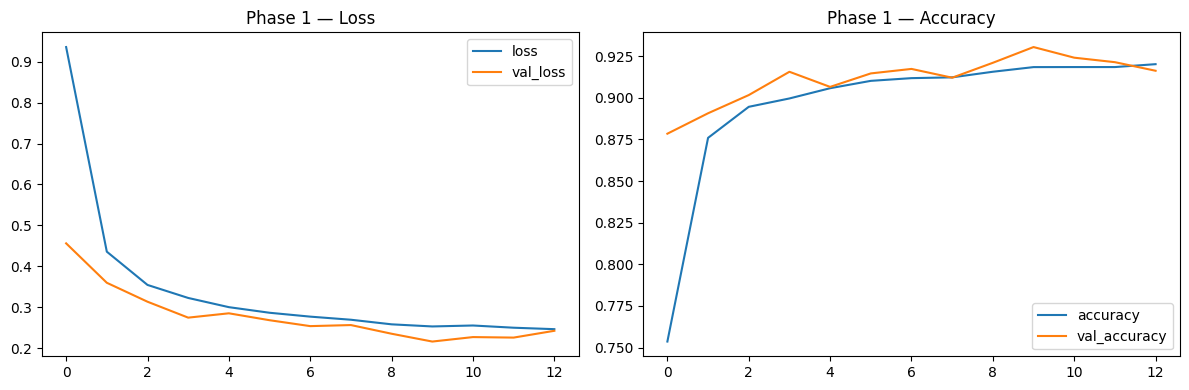

In [16]:
ckpt_p1 = str(MODEL_DIR / 'jalon4_phase1.keras')

callbacks_p1 = [
    tf.keras.callbacks.ModelCheckpoint(
        ckpt_p1, monitor='val_accuracy', save_best_only=True,
    ),
    tf.keras.callbacks.EarlyStopping(
        monitor='val_accuracy', patience=PATIENCE_P1, restore_best_weights=True,
    ),
]

t0 = time.time()
history_p1 = model.fit(
    p1_train_ds,
    validation_data=p1_val_ds,
    epochs=EPOCHS_P1,
    callbacks=callbacks_p1,
)
print(f'Phase 1 terminée en {time.time()-t0:.0f}s')

pd.DataFrame(history_p1.history).to_csv(REPORT_DIR / 'jalon4_phase1_history.csv', index=False)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
pd.DataFrame(history_p1.history)[['loss', 'val_loss']].plot(ax=axes[0], title='Phase 1 — Loss')
pd.DataFrame(history_p1.history)[['accuracy', 'val_accuracy']].plot(ax=axes[1], title='Phase 1 — Accuracy')
plt.tight_layout()
plt.savefig(REPORT_DIR / 'jalon4_phase1_curves.png', dpi=100)
plt.show()

## 10. Phase 2 — PlantWild bridge (25 % backbone dégelé)

Identique à jalon 3 mais patience augmentée (3 → 4) et max_epochs augmenté (20 → 25).
Le bridge PlantWild est fondamental : il pré-adapte le modèle aux images terrain
avant le fine-tuning PlantDoc.

In [17]:
# Dégeler les 25 % de couches les plus profondes du backbone
all_layers = base_model.layers
n_total    = len(all_layers)
n_frozen   = int(n_total * UNFREEZE_RATIO)

for layer in all_layers[:n_frozen]:
    layer.trainable = False
for layer in all_layers[n_frozen:]:
    layer.trainable = True

trainable_p2 = sum(w.numpy().size for w in model.trainable_weights)
total_params  = sum(w.numpy().size for w in model.weights)
print(f'Phase 2 — Backbone : {n_frozen}/{n_total} gelées, {n_total - n_frozen} dégelées')
print(f'Paramètres entraînables : {trainable_p2:,} / {total_params:,} ({100*trainable_p2/total_params:.1f} %)')

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=LR_P2),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy'],
)

Phase 2 — Backbone : 117/157 gelées, 40 dégelées
Paramètres entraînables : 736,238 / 961,046 (76.6 %)


Epoch 1/25
249/250 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.1087 - loss: 9.3561

E0000 00:00:1780152205.496467   15163 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - accuracy: 0.1087 - loss: 9.3442

E0000 00:00:1780152212.882329   15159 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


250/250 ━━━━━━━━━━━━━━━━━━━━ 23s 67ms/step - accuracy: 0.1197 - loss: 6.3726 - val_accuracy: 0.1439 - val_loss: 3.9816 - learning_rate: 1.0000e-04
Epoch 2/25
250/250 ━━━━━━━━━━━━━━━━━━━━ 6s 24ms/step - accuracy: 0.1899 - loss: 3.2426 - val_accuracy: 0.1886 - val_loss: 3.4168 - learning_rate: 1.0000e-04
Epoch 3/25
250/250 ━━━━━━━━━━━━━━━━━━━━ 6s 24ms/step - accuracy: 0.2265 - loss: 2.8833 - val_accuracy: 0.2207 - val_loss: 3.0095 - learning_rate: 1.0000e-04
Epoch 4/25
250/250 ━━━━━━━━━━━━━━━━━━━━ 6s 24ms/step - accuracy: 0.2660 - loss: 2.6675 - val_accuracy: 0.2654 - val_loss: 2.7473 - learning_rate: 1.0000e-04
Epoch 5/25
250/250 ━━━━━━━━━━━━━━━━━━━━ 6s 25ms/step - accuracy: 0.2943 - loss: 2.5316 - val_accuracy: 0.3003 - val_loss: 2.5572 - learning_rate: 1.0000e-04
Epoch 6/25
250/250 ━━━━━━━━━━━━━━━━━━━━ 6s 25ms/step - accuracy: 0.3204 - loss: 2.4000 - val_accuracy: 0.3450 - val_loss: 2.3992 - learning_rate: 1.0000e-04
Epoch 7/25
250/250 ━━━━━━━━━━━━━━━━━━━━ 6s 24ms/step - accuracy: 0.3

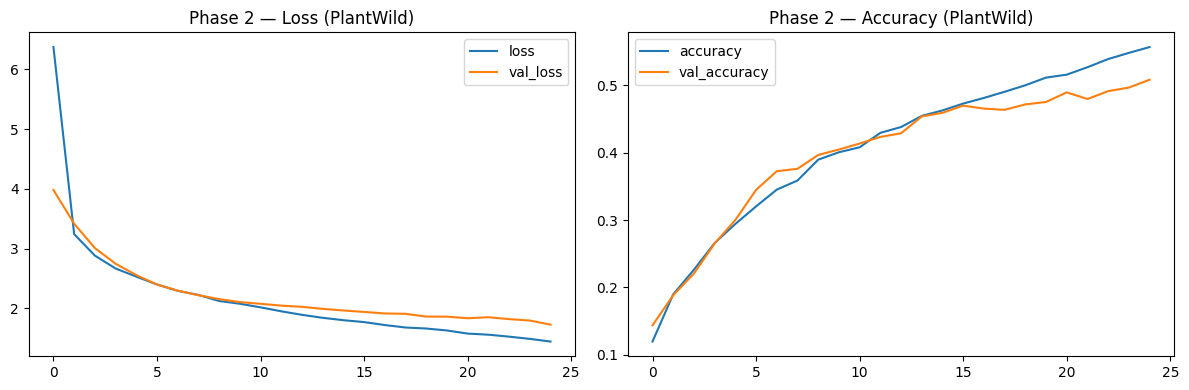

In [18]:
ckpt_p2 = str(MODEL_DIR / 'jalon4_phase2.keras')

callbacks_p2 = [
    tf.keras.callbacks.ModelCheckpoint(
        ckpt_p2, monitor='val_accuracy', save_best_only=True,
    ),
    tf.keras.callbacks.EarlyStopping(
        monitor='val_accuracy', patience=PATIENCE_P2, restore_best_weights=True,
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss', factor=0.5, patience=2, min_lr=1e-7, verbose=1,
    ),
]

t0 = time.time()
history_p2 = model.fit(
    p2_train_ds,
    validation_data=p2_val_ds,
    epochs=EPOCHS_P2,
    callbacks=callbacks_p2,
)
print(f'Phase 2 terminée en {time.time()-t0:.0f}s')

pd.DataFrame(history_p2.history).to_csv(REPORT_DIR / 'jalon4_phase2_history.csv', index=False)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
pd.DataFrame(history_p2.history)[['loss', 'val_loss']].plot(ax=axes[0], title='Phase 2 — Loss (PlantWild)')
pd.DataFrame(history_p2.history)[['accuracy', 'val_accuracy']].plot(ax=axes[1], title='Phase 2 — Accuracy (PlantWild)')
plt.tight_layout()
plt.savefig(REPORT_DIR / 'jalon4_phase2_curves.png', dpi=100)
plt.show()

## 11. Phase 3 — Entraînement mixte PlantDoc + PV replay (Innovation principale)

### Pourquoi 40 % dégelé au lieu de 25 % ?
Avec le replay PV qui protège contre l'oubli, on peut se permettre de dégeler
davantage du backbone sans risquer une dégradation catastrophique.
Cela permet une adaptation plus profonde aux images terrain.

### Pourquoi label smoothing ε = 0.05 ?
PlantDoc n'a que ~70 images/classe en train. Le label smoothing empêche
le modèle de devenir trop confiant sur ces quelques exemples et améliore
la généralisation.

### Pourquoi un schedule cosinus avec warmup ?
Le warmup évite les mises à jour trop larges en début de phase sur un modèle
déjà entraîné. La décroissance cosinus converge plus doucement que ReduceLROnPlateau.

In [19]:
class LabelSmoothingLoss(tf.keras.losses.Loss):
    """Sparse categorical crossentropy avec label smoothing via conversion one-hot.

    tf.keras.losses.SparseCategoricalCrossentropy ne supporte pas label_smoothing
    directement. On passe par une conversion en one-hot pour utiliser
    CategoricalCrossentropy qui le supporte.
    """
    def __init__(self, num_classes, smoothing=0.05, **kwargs):
        super().__init__(**kwargs)
        self.num_classes = num_classes
        self.smoothing   = smoothing

    def call(self, y_true, y_pred):
        y_true_flat = tf.cast(tf.reshape(y_true, [-1]), tf.int32)
        y_one_hot   = tf.one_hot(y_true_flat, self.num_classes)
        return tf.keras.losses.categorical_crossentropy(
            y_one_hot, y_pred, label_smoothing=self.smoothing
        )

    def get_config(self):
        config = super().get_config()
        config.update({'num_classes': self.num_classes, 'smoothing': self.smoothing})
        return config


loss_p3 = LabelSmoothingLoss(num_classes=num_classes, smoothing=LABEL_SMOOTHING_P3)
print(f'LabelSmoothingLoss prête (smoothing={LABEL_SMOOTHING_P3})')

LabelSmoothingLoss prête (smoothing=0.05)


In [20]:
# ── Dégeler 40 % du backbone (vs 25 % en Phase 2) ────────────────────────
all_layers_p3 = base_model.layers
n_total_p3    = len(all_layers_p3)
n_frozen_p3   = int(n_total_p3 * UNFREEZE_RATIO_P3)   # 60 % gelé

for layer in all_layers_p3[:n_frozen_p3]:
    layer.trainable = False
for layer in all_layers_p3[n_frozen_p3:]:
    layer.trainable = True

trainable_p3 = sum(w.numpy().size for w in model.trainable_weights)
total_p3     = sum(w.numpy().size for w in model.weights)
print(f'Phase 3 — Backbone : {n_frozen_p3}/{n_total_p3} gelées, {n_total_p3 - n_frozen_p3} dégelées')
print(f'Paramètres entraînables : {trainable_p3:,} / {total_p3:,} ({100*trainable_p3/total_p3:.1f} %)')

# ── Schedule LR cosinus avec warmup ──────────────────────────────────────
WARMUP_EPOCHS_P3 = 3

def lr_schedule_p3(epoch, lr):
    """Warmup linéaire sur WARMUP_EPOCHS_P3, puis décroissance cosinus."""
    if epoch < WARMUP_EPOCHS_P3:
        return float(LR_P3 * (epoch + 1) / WARMUP_EPOCHS_P3)
    progress = (epoch - WARMUP_EPOCHS_P3) / max(EPOCHS_P3 - WARMUP_EPOCHS_P3, 1)
    cosine   = 0.5 * (1.0 + np.cos(np.pi * progress))
    return float(LR_P3 * (0.01 + 0.99 * cosine))  # LR_P3 → 0.01 × LR_P3

# ── Recompiler avec label smoothing et nouveau LR ────────────────────────
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=LR_P3),
    loss=loss_p3,
    metrics=['accuracy'],
)
print('Modèle recompilé pour Phase 3.')

Phase 3 — Backbone : 94/157 gelées, 63 dégelées
Paramètres entraînables : 788,214 / 961,046 (82.0 %)
Modèle recompilé pour Phase 3.


Epoch 1/60
56/58 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - accuracy: 0.3302 - loss: 2.6836

E0000 00:00:1780152374.346203   15161 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


58/58 ━━━━━━━━━━━━━━━━━━━━ 16s 129ms/step - accuracy: 0.3190 - loss: 2.6699 - val_accuracy: 0.3910 - val_loss: 2.3066 - learning_rate: 1.0000e-05
Epoch 2/60
58/58 ━━━━━━━━━━━━━━━━━━━━ 3s 49ms/step - accuracy: 0.3675 - loss: 2.4168 - val_accuracy: 0.3996 - val_loss: 2.2478 - learning_rate: 2.0000e-05
Epoch 3/60
58/58 ━━━━━━━━━━━━━━━━━━━━ 3s 51ms/step - accuracy: 0.4143 - loss: 2.2480 - val_accuracy: 0.4145 - val_loss: 2.1853 - learning_rate: 3.0000e-05
Epoch 4/60
58/58 ━━━━━━━━━━━━━━━━━━━━ 3s 47ms/step - accuracy: 0.4283 - loss: 2.2068 - val_accuracy: 0.4274 - val_loss: 2.1416 - learning_rate: 3.0000e-05
Epoch 5/60
58/58 ━━━━━━━━━━━━━━━━━━━━ 3s 45ms/step - accuracy: 0.4580 - loss: 2.0615 - val_accuracy: 0.4359 - val_loss: 2.1275 - learning_rate: 2.9977e-05
Epoch 6/60
58/58 ━━━━━━━━━━━━━━━━━━━━ 3s 49ms/step - accuracy: 0.4574 - loss: 2.0782 - val_accuracy: 0.4551 - val_loss: 2.0995 - learning_rate: 2.9910e-05
Epoch 7/60
58/58 ━━━━━━━━━━━━━━━━━━━━ 2s 42ms/step - accuracy: 0.5048 - loss: 1

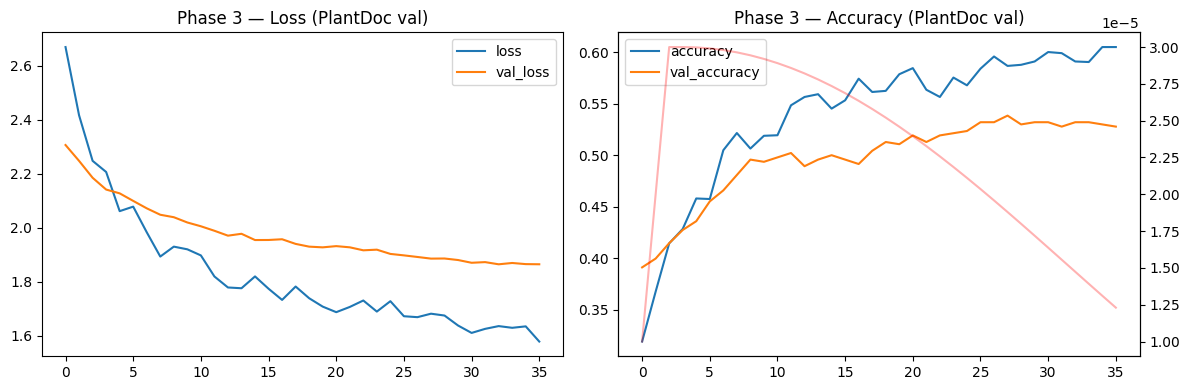

In [21]:
ckpt_p3 = str(MODEL_DIR / 'jalon4_phase3.keras')

callbacks_p3 = [
    # Schedule cosinus avec warmup
    tf.keras.callbacks.LearningRateScheduler(lr_schedule_p3, verbose=0),
    # Sauvegarder le meilleur checkpoint selon val_accuracy PlantDoc
    tf.keras.callbacks.ModelCheckpoint(
        ckpt_p3, monitor='val_accuracy', save_best_only=True,
    ),
    # Early stopping avec patience généreuse (dataset mélangé = convergence plus lente)
    tf.keras.callbacks.EarlyStopping(
        monitor='val_accuracy', patience=PATIENCE_P3, restore_best_weights=True,
    ),
]

t0 = time.time()

# steps_per_epoch définit la durée d\'une "epoch" sur le dataset infini mélangé
# = 1 parcours complet de PlantDoc train (~1 874 / 32 ≈ 58 steps)
history_p3 = model.fit(
    p3_mixed_ds,
    validation_data=p3_val_ds,
    epochs=EPOCHS_P3,
    steps_per_epoch=steps_per_epoch_p3,
    callbacks=callbacks_p3,
)

print(f'Phase 3 terminée en {time.time()-t0:.0f}s')

pd.DataFrame(history_p3.history).to_csv(REPORT_DIR / 'jalon4_phase3_history.csv', index=False)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
pd.DataFrame(history_p3.history)[['loss', 'val_loss']].plot(ax=axes[0], title='Phase 3 — Loss (PlantDoc val)')
pd.DataFrame(history_p3.history)[['accuracy', 'val_accuracy']].plot(ax=axes[1], title='Phase 3 — Accuracy (PlantDoc val)')
lr_col = 'learning_rate' if 'learning_rate' in history_p3.history else 'lr'
pd.DataFrame(history_p3.history)[[lr_col]].plot(ax=axes[1].twinx(), color='red', alpha=0.3, legend=False)
plt.tight_layout()
plt.savefig(REPORT_DIR / 'jalon4_phase3_curves.png', dpi=100)
plt.show()

## 12. Évaluation finale

In [22]:
def evaluate_plantdoc(model, test_dir, mapping, label_to_idx):
    """Évalue le modèle sur le jeu de test PlantDoc et retourne les métriques."""
    images_list, true_labels, pred_labels, pred_confs = [], [], [], []

    for pd_cls, pv_cls in mapping.items():
        cls_dir = test_dir / pd_cls
        if not cls_dir.exists():
            continue
        pv_idx = label_to_idx.get(pv_cls)
        if pv_idx is None:
            continue
        for img_path in sorted(cls_dir.iterdir()):
            if not img_path.is_file():
                continue
            raw = tf.io.read_file(str(img_path))
            img = tf.image.decode_image(raw, channels=3, expand_animations=False)
            img.set_shape([None, None, 3])
            img = tf.image.resize(img, IMG_SIZE)
            img = tf.cast(img, tf.float32)
            images_list.append(img.numpy())
            true_labels.append(pv_idx)

    if not images_list:
        raise ValueError('Aucune image PlantDoc trouvée.')

    images_np = np.array(images_list)
    preds      = model.predict(images_np, batch_size=BATCH_SIZE, verbose=0)
    pred_labels = np.argmax(preds, axis=1).tolist()
    pred_confs  = np.max(preds, axis=1).tolist()

    acc       = accuracy_score(true_labels, pred_labels)
    macro_f1  = f1_score(true_labels, pred_labels, average='macro', zero_division=0)
    mean_conf = float(np.mean(pred_confs))

    return {
        'n_images': len(images_list),
        'n_classes': len(set(true_labels)),
        'accuracy': acc,
        'macro_f1': macro_f1,
        'mean_confidence': mean_conf,
        'true_labels': true_labels,
        'pred_labels': pred_labels,
    }


print('=== Évaluation PlantDoc (test) ===')
pd_results = evaluate_plantdoc(model, PLANTDOC_TEST_DIR, valid_pd_mapping, pv_label_to_idx)

print(f"Images évaluées  : {pd_results['n_images']} / {pd_results['n_classes']} classes")
print(f"Accuracy         : {pd_results['accuracy']*100:.2f} %")
print(f"Macro F1         : {pd_results['macro_f1']*100:.2f} %")
print(f"Confiance moy.   : {pd_results['mean_confidence']*100:.2f} %")

=== Évaluation PlantDoc (test) ===


E0000 00:00:1780152472.053782   15163 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


Images évaluées  : 236 / 27 classes
Accuracy         : 44.49 %
Macro F1         : 42.20 %
Confiance moy.   : 58.35 %



Rapport de classification PlantDoc :
                                            precision    recall  f1-score   support

                        Apple___Apple_scab       0.75      0.30      0.43        10
                  Apple___Cedar_apple_rust       0.27      0.40      0.32        10
                           Apple___healthy       0.25      0.89      0.39         9
                       Blueberry___healthy       0.23      0.27      0.25        11
                          Cherry___healthy       0.25      0.10      0.14        10
Corn___Cercospora_leaf_spot Gray_leaf_spot       0.22      0.50      0.31         4
                        Corn___Common_rust       0.73      0.80      0.76        10
               Corn___Northern_Leaf_Blight       0.75      0.50      0.60        12
                         Grape___Black_rot       0.75      0.38      0.50         8
                           Grape___healthy       0.77      0.83      0.80        12
                           Peach___he

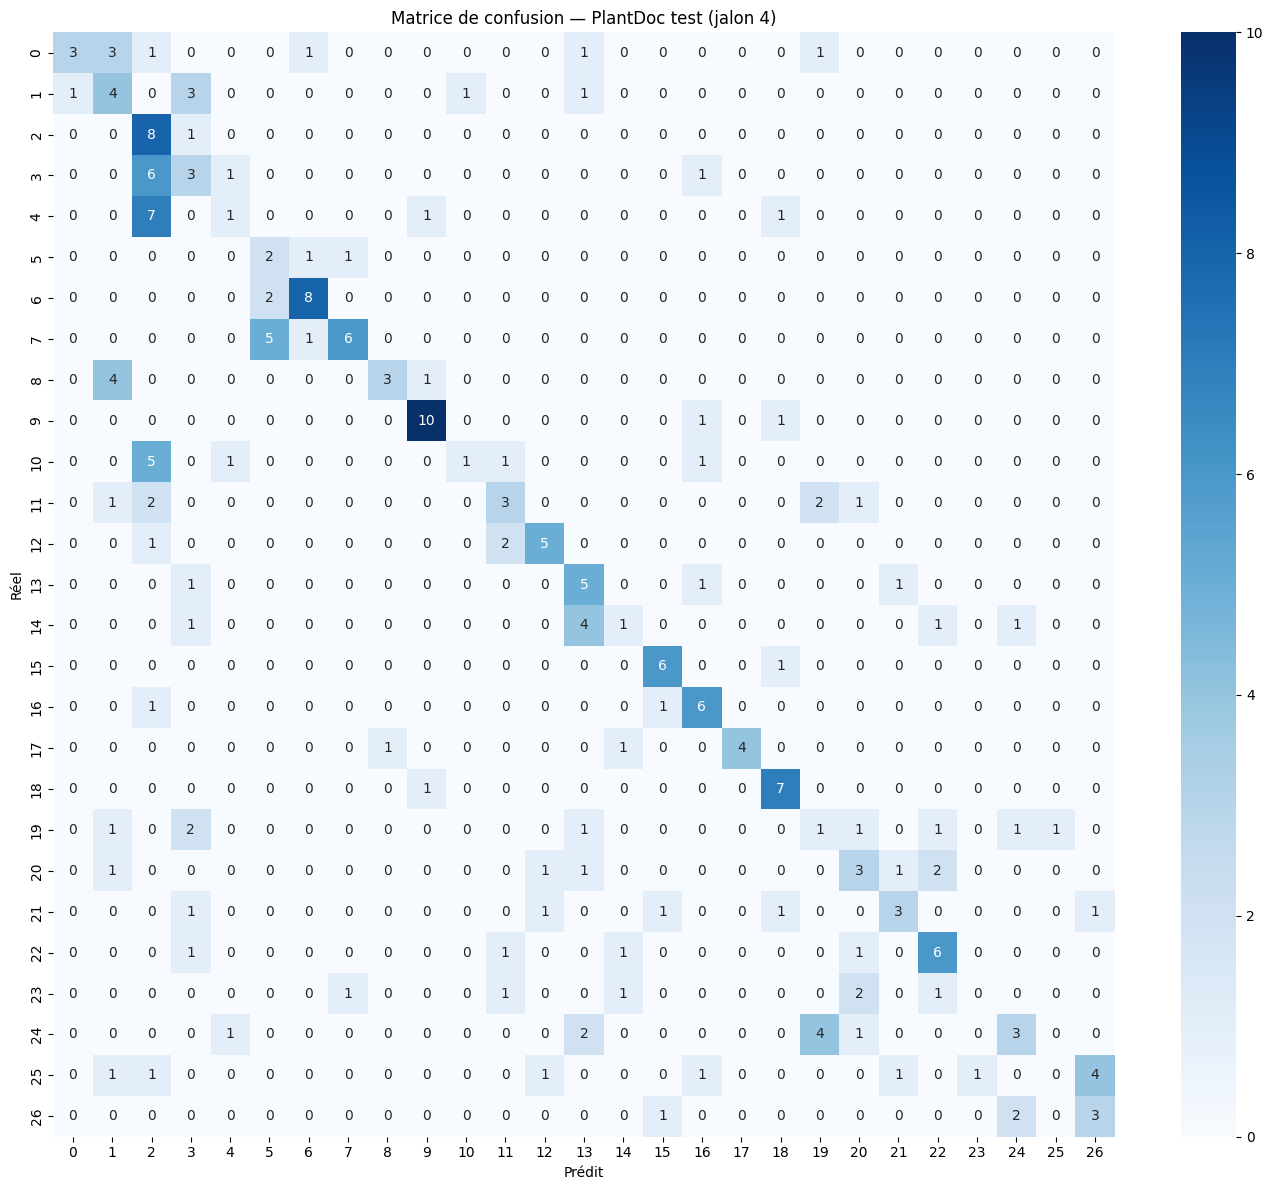

In [23]:
# Rapport de classification PlantDoc
true_names = [class_names[i] for i in pd_results['true_labels']]
pred_names = [class_names[i] for i in pd_results['pred_labels']]
unique_classes = sorted(set(true_names))

print('\nRapport de classification PlantDoc :')
print(classification_report(true_names, pred_names, labels=unique_classes, zero_division=0))

# Matrice de confusion (top classes seulement pour la lisibilité)
cm = confusion_matrix(pd_results['true_labels'], pd_results['pred_labels'],
                      labels=sorted(set(pd_results['true_labels'])))
fig, ax = plt.subplots(figsize=(14, 12))
sns.heatmap(cm, annot=True, fmt='d', ax=ax, cmap='Blues')
ax.set_xlabel('Prédit')
ax.set_ylabel('Réel')
ax.set_title('Matrice de confusion — PlantDoc test (jalon 4)')
plt.tight_layout()
plt.savefig(REPORT_DIR / 'jalon4_plantdoc_confusion_matrix.png', dpi=100)
plt.show()

In [24]:
print('=== Évaluation PlantVillage (test — 38 classes) ===')
y_true_pv, y_pred_pv = [], []

for batch_images, batch_labels in pv_test_ds:
    preds = model.predict(batch_images, verbose=0)
    y_pred_pv.extend(np.argmax(preds, axis=1).tolist())
    y_true_pv.extend(batch_labels.numpy().tolist())

pv_acc = accuracy_score(y_true_pv, y_pred_pv)
pv_f1  = f1_score(y_true_pv, y_pred_pv, average='macro', zero_division=0)

print(f'Images évaluées  : {len(y_true_pv):,}')
print(f'Accuracy         : {pv_acc*100:.2f} %')
print(f'Macro F1         : {pv_f1*100:.2f} %')

=== Évaluation PlantVillage (test — 38 classes) ===


E0000 00:00:1780152484.017567   15164 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


Images évaluées  : 8,145
Accuracy         : 57.93 %
Macro F1         : 52.05 %


In [25]:
pd_acc_str = f"{pd_results['accuracy']*100:.2f} %"
pd_f1_str  = f"{pd_results['macro_f1']*100:.2f} %"
pv_acc_str = f'{pv_acc*100:.2f} %'
pv_f1_str  = f'{pv_f1*100:.2f} %'
conf_str   = f"{pd_results['mean_confidence']*100:.2f} %"

print('\n' + '='*80)
print('TABLEAU COMPARATIF — AgroScan')
print('='*80)
header = f"{'Modèle':<42} {'PDoc Acc':>10} {'PDoc F1':>10} {'PV Acc':>10} {'PV F1':>10}"
print(header)
print('-' * len(header))

rows = [
    ('Baseline (jalon 2)',                   '22.88 %', '17.39 %', '94.98 %', '93.63 %'),
    ('PV→PDoc direct amélioré',              '37.29 %', '31.19 %', '71.34 %', '63.02 %'),
    ('PV→Wild→PDoc (jalon 3 plantwild)',     '53.39 %', '52.13 %', '42.77 %', '38.97 %'),
    ('Dégel total jalon 3 (expérience)',     '25.85 %', '18.75 %', '80.43 %', '76.45 %'),
    ('Mixte+Aug. renforcée (jalon 4)  ◄◄◄', pd_acc_str, pd_f1_str, pv_acc_str, pv_f1_str),
]

for name, pd_a, pd_f, pv_a, pv_f in rows:
    print(f'{name:<42} {pd_a:>10} {pd_f:>10} {pv_a:>10} {pv_f:>10}')

print('='*80)
print(f'Confiance moyenne PlantDoc (jalon 4) : {conf_str}')

# Sauvegarder les résultats
results = {
    'plantdoc_accuracy': float(pd_results['accuracy']),
    'plantdoc_macro_f1': float(pd_results['macro_f1']),
    'plantdoc_mean_confidence': float(pd_results['mean_confidence']),
    'plantvillage_accuracy': float(pv_acc),
    'plantvillage_macro_f1': float(pv_f1),
}
with open(REPORT_DIR / 'jalon4_results.json', 'w') as f:
    json.dump(results, f, indent=2)
print('\nRésultats sauvegardés dans reports/jalon4_results.json')


TABLEAU COMPARATIF — AgroScan
Modèle                                       PDoc Acc    PDoc F1     PV Acc      PV F1
--------------------------------------------------------------------------------------
Baseline (jalon 2)                            22.88 %    17.39 %    94.98 %    93.63 %
PV→PDoc direct amélioré                       37.29 %    31.19 %    71.34 %    63.02 %
PV→Wild→PDoc (jalon 3 plantwild)              53.39 %    52.13 %    42.77 %    38.97 %
Dégel total jalon 3 (expérience)              25.85 %    18.75 %    80.43 %    76.45 %
Mixte+Aug. renforcée (jalon 4)  ◄◄◄           44.49 %    42.20 %    57.93 %    52.05 %
Confiance moyenne PlantDoc (jalon 4) : 58.35 %

Résultats sauvegardés dans reports/jalon4_results.json


In [26]:
# ── Sauvegarde finale ─────────────────────────────────────────────────────
final_model_path = MODEL_DIR / 'agroscan_jalon4.keras'
model.save(final_model_path)
print(f'Modèle sauvegardé : {final_model_path}')
print(f'Taille             : {final_model_path.stat().st_size / 1024 / 1024:.2f} MB')

# Export TFLite optionnel (quantification dynamique)
try:
    converter = tf.lite.TFLiteConverter.from_keras_model(model)
    converter.optimizations = [tf.lite.Optimize.DEFAULT]
    tflite_model = converter.convert()
    tflite_path = MODEL_DIR / 'agroscan_jalon4_dynamic_quant.tflite'
    tflite_path.write_bytes(tflite_model)
    print(f'TFLite sauvegardé  : {tflite_path} ({tflite_path.stat().st_size/1024:.0f} KB)')
except Exception as e:
    print(f'Export TFLite ignoré : {e}')

Modèle sauvegardé : /home/leonard/UQAC/8INF934 - Atelier Pratique IA I/Projet/AgroScan/models/agroscan_jalon4.keras
Taille             : 10.26 MB
INFO:tensorflow:Assets written to: /tmp/tmpan9i28gs/assets


INFO:tensorflow:Assets written to: /tmp/tmpan9i28gs/assets


Saved artifact at '/tmp/tmpan9i28gs'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name='keras_tensor_196')
Output Type:
  TensorSpec(shape=(None, 38), dtype=tf.float32, name=None)
Captures:
  140338279675856: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140338258829840: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140338190556752: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140338190557136: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140338258829264: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140338190555792: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140338066867600: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140338066867408: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140338190556944: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140338190556560: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140338066

W0000 00:00:1780152487.639585   15018 tf_tfl_flatbuffer_helpers.cc:364] Ignored output_format.
W0000 00:00:1780152487.639595   15018 tf_tfl_flatbuffer_helpers.cc:367] Ignored drop_control_dependency.
